In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics import  accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import seaborn as sns
import json
from sklearn.model_selection import StratifiedKFold

In [16]:
print("Loading PubMedQA dataset...")
dataset = load_dataset("pubmed_qa", "pqa_labeled")
model_name = 'NeuML/pubmedbert-base-embeddings'
encoder = SentenceTransformer(model_name)

questions = [row['question'] for row in dataset['train']]
contexts = [row['context']['contexts'][-1] for row in dataset['train']]
labels = [row['final_decision'] for row in dataset['train']]

print(f"Encoding sequences using {model_name}...")
Q = encoder.encode(questions, show_progress_bar=True) 
C = encoder.encode(contexts, show_progress_bar=True)   

Loading PubMedQA dataset...
Encoding sequences using NeuML/pubmedbert-base-embeddings...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [17]:
with open('test_ground_truth.json', 'r') as f:
    ground_truth = json.load(f)
test_ids = set(ground_truth.keys())

all_ids = [row['pubid'] for row in dataset['train']]
all_labels = [row['final_decision'] for row in dataset['train']]
dev_indices = [i for i, pid in enumerate(all_ids) if str(pid) not in test_ids]
test_indices = [i for i, pid in enumerate(all_ids) if str(pid) in test_ids]

def build_interaction_space(Q, C):
    abs_diff = np.abs(Q - C)
    elementwise_prod = Q * C
    return np.hstack([abs_diff, elementwise_prod])

X = build_interaction_space(Q, C) 
y = np.array(labels)

X_dev, y_dev = X[dev_indices], y[dev_indices]
X_test, y_test = X[test_indices], y[test_indices]
print(f"Dev size: {len(X_dev)} | Test size: {len(X_test)}")

Dev size: 500 | Test size: 500


In [ ]:
fold_accuracies = []
fold_f1s = []
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scalers = []
models = []

for train_index, val_idx in skf.split(X_dev, y_dev):
    X_train, X_val = X[train_index], X[val_idx]
    y_train, y_val = y[train_index], y[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    lda_clf = LinearDiscriminantAnalysis()
    lda_clf.fit(X_train_scaled, y_train)
    
    preds = lda_clf.predict(X_val_scaled)
    fold_accuracies.append(accuracy_score(y_val, preds))
    fold_f1s.append(f1_score(y_val, preds, average='macro'))
    scalers.append(scaler)
    models.append(lda_clf)

print(f"Mean Accuracy: {np.mean(fold_accuracies):.3f}")
print(f"Mean Macro F1: {np.mean(fold_f1s):.3f}")

Mean Accuracy: 0.498
Mean Macro F1: 0.326


In [22]:
all_probs = []
for scaler, classifier in zip(scalers, models):
    X_test_scaled = scaler.transform(X_test)
    probs = classifier.predict_proba(X_test_scaled) 
    all_probs.append(probs)

class_names = models[0].classes_
mean_probs = np.mean(all_probs, axis=0)
ensemble_preds = np.argmax(mean_probs, axis=1)
ensemble_preds_strings = [class_names[p] for p in ensemble_preds]
print(f"Ensemble Test Accuracy: {accuracy_score(y_test, ensemble_preds_strings):.3f}")
print(f"Ensemble Test Macro F1: {f1_score(y_test, ensemble_preds_strings, average='macro'):.3f}")

Ensemble Test Accuracy: 0.622
Ensemble Test Macro F1: 0.550


Projecting Test set into LDA space...


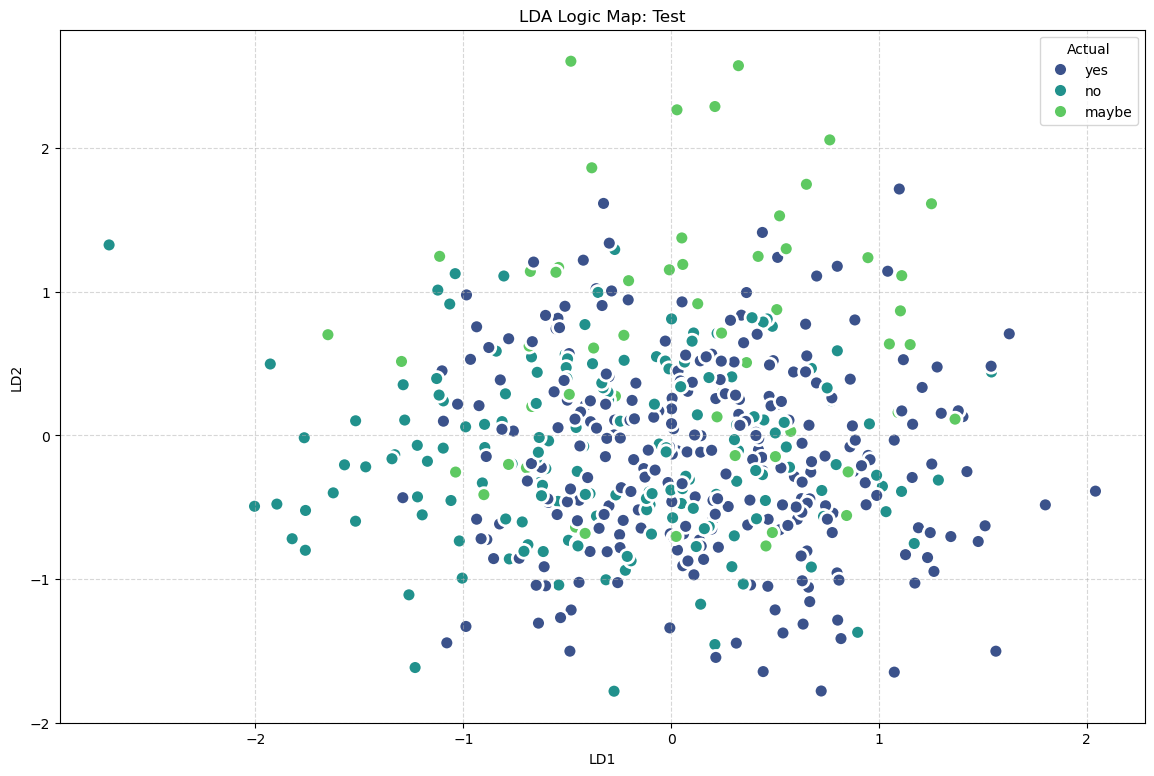

In [26]:
print("Projecting Test set into LDA space...")
all_coords = []
for scaler, classifier in zip(scalers, models):
    X_test_scaled = scaler.transform(X_test)
    coords = classifier.transform(X_test_scaled) 
    all_coords.append(coords)

mean_coords = np.mean(all_coords, axis=0)
df_viz = pd.DataFrame({
    'LD1': mean_coords[:, 0],
    'LD2': mean_coords[:, 1],
    'Predicted': ensemble_preds_strings, 
    'Actual': y_test                     
})

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_viz, x='LD1', y='LD2', hue='Actual', markers={'Test': 'o'}, s=100, linewidth=2, palette='viridis'
)
plt.title("LDA Logic Map: Test")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()